In [20]:
import os
import openmc
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm , Normalize


In [21]:
# pulizia per sicurezza

os.system("rm *.h5")
os.system("rm *.xml")
os.system("rm *.out")
os.system("rm *.png")

0

VARIABILI IMPORTANTI

In [22]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}

p = load_parameters('../parametri.txt')


# --- Parametri Geometrici ---
R_CORE    = p['R_CORE']
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']

# --- Parametri Logici ---
R_PIPE    = p['R_PIPE']

# --- Parametri Pin/Lattice ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']
PITCH     = p['PITCH']

# --- Parametri Target ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']

# --- Sorgente e Simulazione ---
S             = p['S']
photon_energy = p['photon_energy']
bin_ris       = p['bin_ris']
batches       = p['batches']
particles     = p['particles']
inactive      = p['inactive']
arricchimento = p['arricchimento']

MATERIALI

In [23]:
fuel = openmc.Material(name='fuel')
fuel.add_nuclide('U235', arricchimento)
fuel.add_nuclide('U238', 1.0 - arricchimento)
fuel.add_nuclide('O16', 2.0)
fuel.set_density('g/cm3', 10.96)

# materiale di rivestimento
cladding = openmc.Material (name = 'cladding')
cladding.add_element('Zr', 1.0) 
cladding.set_density('g/cm3', 6.49)

# materiale di moderatore
water = openmc.Material (name = 'water')
water.add_nuclide('H2', 2.0)
water.add_element('O', 1.0)
water.set_density('g/cm3', 1.10)
water.add_s_alpha_beta('c_D_in_D2O') # aggiungo la tabella di scattering termico
# n.b.  le sezioni d'urto veloci sono già incluse di default

# aggiungo unriflettore in ACCIAIO INOX
# Usiamo SS316 che è standard, denso e riflette senza moderare troppo
reflector = openmc.Material(name='reflector')
reflector.add_element('Fe', 0.65)
reflector.add_element('Cr', 0.17)
reflector.add_element('Ni', 0.12)
reflector.add_element('Mo', 0.02)
reflector.add_element('Mn', 0.02)
reflector.set_density('g/cm3', 7.9) # Densità alta per riflettere bene

# voglio una sorgente puntiforme di neutroni in un punto specifico
marker_mat = openmc.Material(name='marker')
marker_mat.set_density('g/cm3', 1e-10) # Densità quasi nulla per non disturbare la fisica
marker_mat.add_nuclide('He4', 1.0) # elio, non interagisce praticamente

# Carburo di Boro B4C per le barre di controllo
control_rod = openmc.Material(name='B4C')
control_rod.add_element('B', 4.0)
control_rod.add_element('C', 1.0)
control_rod.set_density('g/cm3', 2.52) # Densità teorica B4C

mat_target = fuel # dal paper di lorenzo si nota un otttimo per U2O

materials = openmc.Materials([fuel, cladding, water, reflector, marker_mat])

materials.cross_sections = "/home/bossi_ricky/openmc_data/mcnp_endfb71/cross_sections.xml" # per fotonucleari

materials.export_to_xml()

GEOMETRIA

In [24]:
# --- 0. PIANI Z (ASSOLUTI) ---
z_bot_ref = openmc.ZPlane(z0=-REF_BOT, boundary_type='vacuum')
z_bot_core = openmc.ZPlane(z0=0.0)
z_top_core = openmc.ZPlane(z0=H_CORE)
z_top_world = openmc.ZPlane(z0=H_CORE + 5.0, boundary_type='vacuum')

# Piani Z Target
z_mid = H_CORE - P_TARGET
z_tgt_bot = openmc.ZPlane(z0=z_mid - (H_TARGET / 2.0))
z_tgt_top = openmc.ZPlane(z0=z_mid + (H_TARGET / 2.0))

# Superficie Sorgente
sphere_src = openmc.Sphere(x0=0, y0=0, z0=H_CORE + 2, r=0.5)

# --- 1. CALCOLO DIMENSIONI TAGLIO CENTRALE ---
# Calcoliamo quanto deve essere grande il buco esagonale centrale
# Rimuoviamo gli anelli che cadono dentro R_PIPE
n_rings_removed = int(np.ceil(R_PIPE / PITCH))
# Il lato del prisma che useremo per "bucare" il lattice:
EDGE_PIPE_LARGE = (n_rings_removed - 0.5) * PITCH
if EDGE_PIPE_LARGE == 0: EDGE_PIPE_LARGE = PITCH # Sicurezza minima

# --- 2. FORME GEOMETRICHE BASE ---

EDGE_FUEL = R_FUEL
EDGE_CLAD = R_FUEL + CLAD_THICK

# A. Prismi PIN
hex_fuel_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_FUEL, orientation='x')
hex_clad_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_CLAD, orientation='x')

# B. Prisma "TAGLIO" CENTRALE (Il buco grande nel reticolo)
hex_pipe_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_PIPE_LARGE, orientation='x')

# C. Cilindro Target (Unico centrale)
cyl_target = openmc.ZCylinder(r=R_TARGET)


# --- 3. UNIVERSI ---

# A. Universo PIN (Fuel -> Clad -> Water)
c_fuel = openmc.Cell(fill=fuel, region=hex_fuel_prism)
c_clad = openmc.Cell(fill=cladding, region=hex_clad_prism & ~hex_fuel_prism)
# Acqua definita "ovunque fuori dal cladding". Il confine sarà dato dal lattice.
c_water_pin = openmc.Cell(fill=water, region=~hex_clad_prism)

u_pin = openmc.Universe(cells=[c_fuel, c_clad, c_water_pin])


# C. Universo ACQUA ESTERNA (Riflettore/Gap)
c_water_full = openmc.Cell(fill=water)
u_water = openmc.Universe(cells=[c_water_full])


# --- 4. LATTICE (SOLO COMBUSTIBILE) ---
# Creiamo un lattice uniforme pieno SOLO di pin.
# Il buco centrale lo creiamo geometricamente nello step successivo, non qui.

num_rings = int(np.ceil(R_CORE / PITCH)) + 1
hex_core_edge = num_rings * PITCH
hex_ref_edge = hex_core_edge + REF_SIDE

lattice_universes = []
for i in range(num_rings):
    if i == 0:
        lattice_universes.append([u_pin])
    else:
        lattice_universes.append([u_pin] * (6 * i))

lattice = openmc.HexLattice(name='core_hex_lattice')
lattice.center = (0.0, 0.0)
lattice.pitch = (PITCH,)
lattice.outer = u_water
lattice.universes = lattice_universes[::-1] # Inversione fondamentale: Esterno -> Interno
lattice.orientation = 'x'

# --- 5. ASSEMBLAGGIO FINALE (GEOMETRIA DIRETTA) ---

prism_core = openmc.model.get_hexagonal_prism(edge_length=hex_core_edge, orientation='x')
prism_reflector = openmc.model.get_hexagonal_prism(edge_length=hex_ref_edge, orientation='x', boundary_type='vacuum')

# A. Cella Core (Lattice CON BUCO)
# ---------------------------------------------------------
# Prendiamo il prisma grande del core, e sottraiamo (~) il prisma del canale centrale.
# In questo modo il lattice viene "tagliato" via dal centro.
region_core = prism_core & ~hex_pipe_prism & +z_bot_core & -z_top_core
c_main_core = openmc.Cell(fill=lattice, region=region_core)


# B. Canale Centrale (Target + Vuoto) - DEFINIZIONE DIRETTA
# ---------------------------------------------------------
# 1. Definiamo il volume TOTALE del canale esagonale (da 0 a H_CORE)
region_central_hex_total = hex_pipe_prism & +z_bot_core & -z_top_core

# 2. Definiamo la regione del TARGET SOLIDO (Cilindro limitato in Z)
# Nota: Intersechiamo con region_central_hex_total per sicurezza, ma basterebbe il cilindro.
region_target_solid = region_central_hex_total & -cyl_target & +z_tgt_bot & -z_tgt_top

# 3. Definiamo la regione del VUOTO (Tutto il canale MENO il target)
# Usiamo l'operatore ~ (NOT) sulla regione del target.
region_void_gap = region_central_hex_total & ~region_target_solid

# Creazione delle celle
c_target = openmc.Cell(fill=mat_target, region=region_target_solid)
c_void_gap = openmc.Cell(fill=None, region=region_void_gap) # fill=None è FONDAMENTALE


# C. Riflettori (Rimangono uguali)
region_ref_side = prism_reflector & ~prism_core & +z_bot_core & -z_top_core
c_ref_side = openmc.Cell(fill=reflector, region=region_ref_side)

region_ref_bot = prism_reflector & +z_bot_ref & -z_bot_core
c_ref_bot = openmc.Cell(fill=reflector, region=region_ref_bot)

# D. Top World & Source (Rimangono uguali)
c_source_marker = openmc.Cell(fill=marker_mat, region=-sphere_src)
region_top = prism_reflector & +z_top_core & -z_top_world & +sphere_src
c_top_void = openmc.Cell(fill=None, region=region_top)

all_cells = [c_main_core, c_target, c_void_gap, c_ref_side, c_ref_bot, c_source_marker, c_top_void]
geometry = openmc.Geometry(all_cells)
geometry.export_to_xml()
print("Geometria generata correttamente.")

def count_fuel_pins(num_rings, pitch, r_pipe, r_core):
    total_pins = 0
    # Ring 0 è il centro
    for i in range(num_rings):
        ring_radius = i * pitch
        # Se l'anello è fuori dalla pipe centrale e dentro il raggio del core
        if ring_radius >= r_pipe and ring_radius <= r_core:
            if i == 0:
                total_pins += 1
            else:
                total_pins += (6 * i)
    return total_pins

n_barre = count_fuel_pins(num_rings, PITCH, R_PIPE, R_CORE)
print(f"Numero di barre di combustibile effettive: {n_barre} \n\n")

Geometria generata correttamente.
Numero di barre di combustibile effettive: 210 




/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:130: FutureWarning: get_hexagonal_prism(...) has been renamed hexagonal_prism(...). Future versions of OpenMC will not accept get_hexagonal_prism.
  warn("get_hexagonal_prism(...) has been renamed hexagonal_prism(...). "
/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:121: FutureWarning: The hexagonal_prism(...) function has been replaced by the HexagonalPrism(...) class. Future versions of OpenMC will not accept hexagonal_prism.
  warn("The hexagonal_prism(...) function has been replaced by the "


PLOTTING

/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/plots.py:1307: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(



VISUALIZZAZIONE GEOMETRIA

1. VISTA DALL'ALTO (Piano XY nel Core)


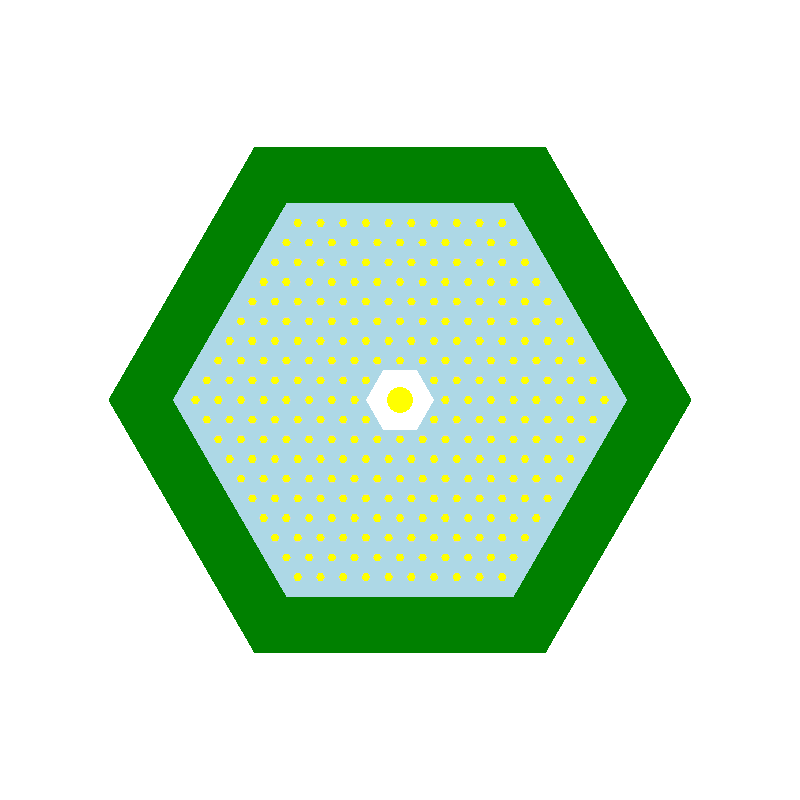

2. VISTA LATERALE (Piano XZ)


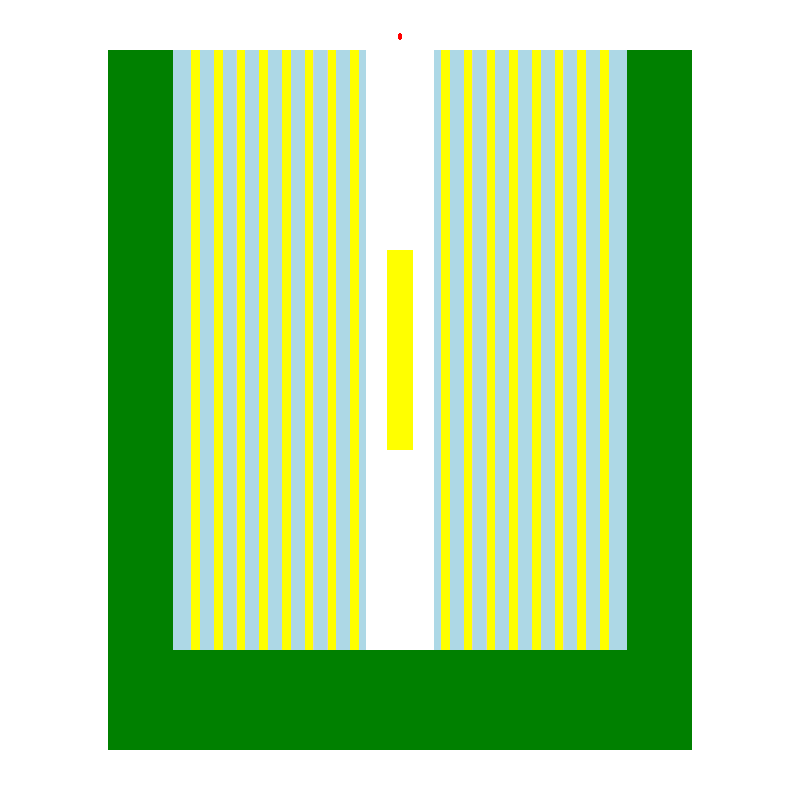


--- LEGENDA COLORI ---
■ yellow          : fuel
■ lightgray       : cladding
■ lightblue       : water
■ green           : reflector
■ red             : marker


In [25]:
color_map = {
    fuel: 'yellow',         # Combustibile
    cladding: 'lightgray',  # Cladding
    water: 'lightblue',     # Moderatore (acqua)
    reflector: 'green',     # Riflettore
    marker_mat: 'red'      # Marker sorgente
}

# A. Vista dall'alto (Sezione nel mezzo del core)
p1 = openmc.Plot()
p1.basis = 'xy'
p1.origin = (0.0, 0.0, H_CORE / 2.0)
p1.width = (3 * (R_CORE + REF_SIDE + 2.0), 3 * (R_CORE + REF_SIDE + 2.0))
p1.pixels = (800, 800)
p1.color_by = 'material'
p1.colors = color_map
p1.filename = 'reactor_xy'

# B. Vista laterale (Sezione verticale XZ)
p2 = openmc.Plot()
p2.basis = 'xz'
p2.origin = (0.0, 0.0, (H_CORE - REF_BOT) / 2.0) 
p2.width = (3 * (R_CORE + REF_SIDE + 2.0), H_CORE + REF_BOT + 15.0)
p2.pixels = (800, 800)
p2.color_by = 'material'
p2.colors = color_map
p2.filename = 'reactor_xz'

# Esporto tutti i plot nel file XML
plots = openmc.Plots([p1, p2])
plots.export_to_xml()

# Eseguo il plotter: ho rimosso open_browser=False che causava l'errore
# OpenMC genererà i file .png basandosi sui nomi definiti (reactor_xy.png, ecc.)
openmc.plot_geometry() 

print("\n" + "="*30)
print("VISUALIZZAZIONE GEOMETRIA")
print("="*30 + "\n")

print("1. VISTA DALL'ALTO (Piano XY nel Core)")
display(Image('reactor_xy.png'))

print("2. VISTA LATERALE (Piano XZ)")
display(Image('reactor_xz.png'))

# Legenda finale
print("\n--- LEGENDA COLORI ---")
for mat, col in color_map.items():
    print(f"■ {col.ljust(15)} : {mat.name}")

SETTINGS FIXED

In [26]:
source = openmc.IndependentSource()

# Definisco la sorgente: un punto sopra l'imboccatura del canale
# Il canale è centrato in (0,0) nel piano XY e parte da Z = half_width
source_pos = openmc.stats.Point((0, 0, H_CORE + 2.0))
# Direzione: verso il basso (lungo l'asse Z negativo)
source_dir = openmc.stats.Monodirectional((0, 0, -1))
# Energia
source_energy = openmc.stats.Discrete([photon_energy], [1.0]) 
source.particle = 'photon'

settings = openmc.Settings()
settings.batches = batches
settings.particles = particles
settings.run_mode = 'fixed source' # simulazione a sorgente fissata

settings.source = source

settings.photon_transport = True
settings.photonuclear_physics = True
settings.create_fission_neutrons = True

settings.export_to_xml()

# METTI TRACKING DEI NEUTRONI

TALLIES

In [27]:
tallies = openmc.Tallies()

# --- A. MESH E TALLY ASSIALE ---
mesh_z = openmc.RegularMesh()
mesh_z.dimension = [1, 1, bin_ris]
mesh_z.lower_left = [-R_CORE, -R_CORE, 0.0]
mesh_z.upper_right = [R_CORE, R_CORE, H_CORE]

# --- B. MESH E TALLY 2D (MAPPA FISSIONI) ---
bound_xy = R_CORE + REF_SIDE + 2.0 
mesh_2d = openmc.RegularMesh()
mesh_2d.dimension = [bin_ris, bin_ris, 1]
mesh_2d.lower_left = [-bound_xy, -bound_xy, H_CORE/2.0 - 0.5]
mesh_2d.upper_right = [bound_xy, bound_xy, H_CORE/2.0 + 0.5]

# --- C.  TALLY MESH XZ (VISTA LATERALE) ---
bound_x = R_CORE + REF_SIDE + 2.0
bound_z = H_CORE + 5.0   # margine SOLO sopra
mesh_xz = openmc.RegularMesh()
mesh_xz.dimension = [bin_ris, 1, bin_ris]
mesh_xz.lower_left = [-bound_x, -0.5, 0.0]
mesh_xz.upper_right = [ bound_x,  0.5, bound_z]

# ---------------------------------------------------------------------------------------------------------------------

# --- Tally per i profili assiali di neutroni e fotoni ---
tally_n = openmc.Tally(name='profilo_neutroni')
tally_n.filters = [openmc.MeshFilter(mesh_z), openmc.ParticleFilter(['neutron'])]
tally_n.scores = ['flux']
tallies.append(tally_n)

tally_p = openmc.Tally(name='profilo_fotoni')
tally_p.filters = [openmc.MeshFilter(mesh_z), openmc.ParticleFilter(['photon'])]
tally_p.scores = ['flux']
tallies.append(tally_p)

# Tally mappa fissioni
tally_map = openmc.Tally(name='mappa_fissioni')
tally_map.filters = [openmc.MeshFilter(mesh_2d)]
tally_map.scores = ['nu-fission', 'fission', 'absorption', 'flux' , 'total']
tallies.append(tally_map)

#  Tally  vista laterale fissioni
tally_xz = openmc.Tally(name='mappa_fissioni_xz')
tally_xz.filters = [openmc.MeshFilter(mesh_xz)]
tally_xz.scores = ['nu-fission', 'fission', 'absorption', 'flux' , 'total']
tallies.append(tally_xz)

# Tally spettro energetico totale (neutroni + fotoni)
energies = np.logspace(-1, 7, 501)
tally_spec = openmc.Tally(name='spettro_energetico')
tally_spec.filters = [openmc.EnergyFilter(energies)]
tally_spec.scores = ['flux']
tallies.append(tally_spec)

# Tally per spettro con cui nascono i neutroni (chi)
tally_chi = openmc.Tally(name='spettro_chi')
tally_chi.filters = [openmc.EnergyFilter(np.logspace(-5, 7, 501)), 
                     openmc.MaterialFilter(fuel)]
tally_chi.scores = ['nu-fission'] 
tallies.append(tally_chi)


tallies.export_to_xml()


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=10.
  warn(msg, IDWarning)


In [ ]:
percorso_eseguibile = "/home/bossi_ricky/miniconda3/envs/openmc-env/bin/openmc"
openmc.run(openmc_exec=percorso_eseguibile)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [ ]:
#Apertura delle tallies
sp = openmc.StatePoint(f'statepoint.{batches}.h5')

Profilo Neutronico e fotonico lungo l'asse del reattore

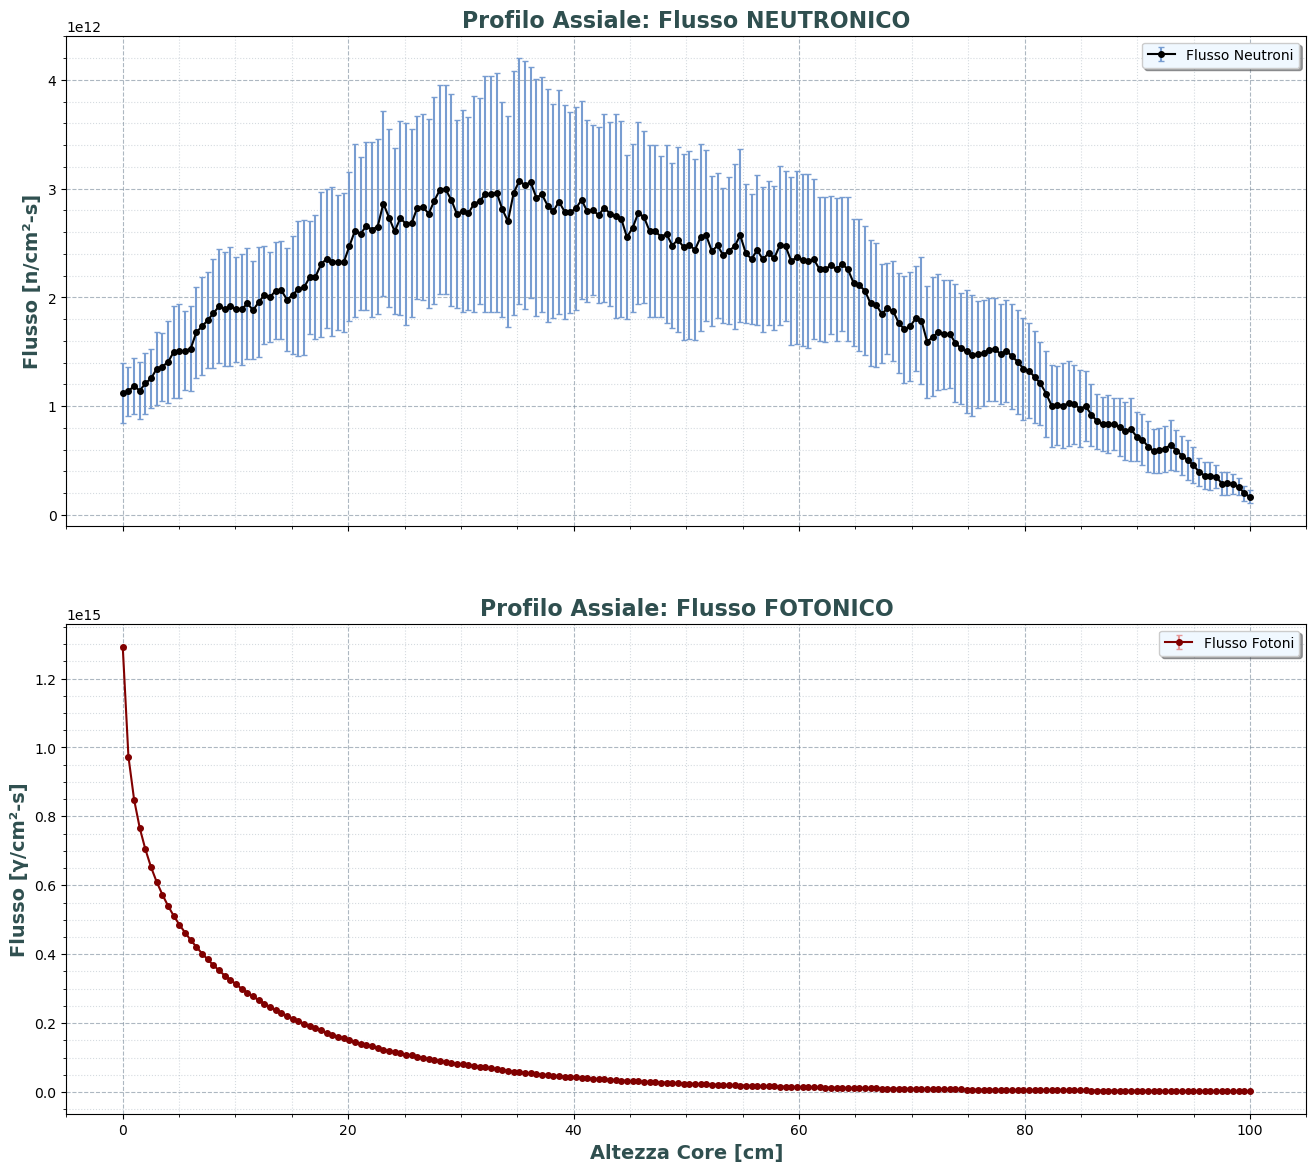

In [ ]:
t_n = sp.get_tally(name='profilo_neutroni')
t_p = sp.get_tally(name='profilo_fotoni')

# Neutroni
n_mean = t_n.get_values(scores=['flux'], value='mean').flatten() * S
n_std  = t_n.get_values(scores=['flux'], value='std_dev').flatten() * S
# Fotoni
p_mean = t_p.get_values(scores=['flux'], value='mean').flatten() * S
p_std  = t_p.get_values(scores=['flux'], value='std_dev').flatten() * S

# Asse Z
z_coords = np.linspace(0.0, 100.0, len(n_mean))

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14), sharex=True)
plt.subplots_adjust(hspace=0.2)

# --- PLOT 1: NEUTRONI ---
ax1.errorbar(z_coords, n_mean, yerr=n_std, fmt='-o', markersize=4,
             color='#000000', ecolor='#789DD1', capsize=2, label='Flusso Neutroni')
ax1.set_title('Profilo Assiale: Flusso NEUTRONICO', fontsize=16, fontweight='bold', color='#2F4F4F')
ax1.set_ylabel('Flusso [n/cm²-s]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.set_xlabel('Altezza Core [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax1.minorticks_on()
ax1.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax1.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax1.legend(loc='upper right', frameon=True, shadow=True, facecolor='#F0F8FF')

# --- PLOT 2: FOTONI ---
ax2.errorbar(z_coords, p_mean, yerr=p_std, fmt='-o', markersize=4,
             color='#800000', ecolor='#E69999', capsize=2, label='Flusso Fotoni')
ax2.set_title('Profilo Assiale: Flusso FOTONICO', fontsize=16, fontweight='bold', color='#2F4F4F')
ax2.set_xlabel('Altezza Core [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.set_ylabel('Flusso [γ/cm²-s]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.minorticks_on()
ax2.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax2.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax2.legend(loc='upper right', frameon=True, shadow=True, facecolor='#F0F8FF')

plt.show()

Profilo Neutronico in una slice orizzontale del reattore

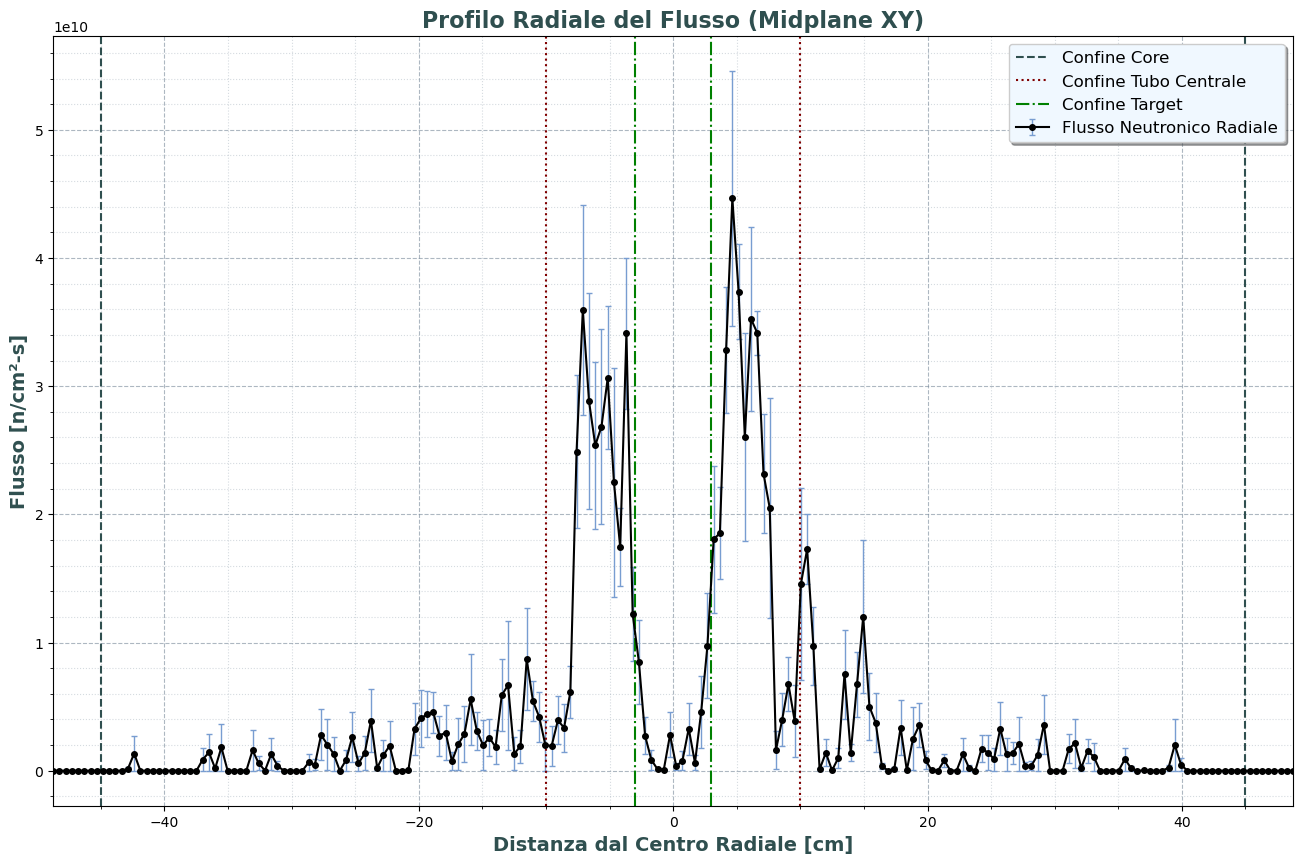

In [ ]:
tally_xy_res = sp.get_tally(name='mappa_fissioni')

# Estraiamo il flusso e calcoliamo la deviazione standard per coerenza stilistica
flux_xy = tally_xy_res.get_values(scores=['flux'], value='mean').reshape((bin_ris, bin_ris))
flux_std = tally_xy_res.get_values(scores=['flux'], value='std_dev').reshape((bin_ris, bin_ris))

# Normalizzazione con l'intensità della sorgente S
flux_xy *= S
flux_std *= S

# --- SLICING (Taglio centrale lungo l'asse X) ---
mid_index = flux_xy.shape[0] // 2
flux_radial = flux_xy[mid_index, :]
std_radial = flux_std[mid_index, :]

# Creazione asse X centrato
bound_xy = R_CORE + REF_SIDE/4
x_coords = np.linspace(-bound_xy, bound_xy, bin_ris)

# --- PLOTTING ---
plt.figure(figsize=(16, 10))

plt.errorbar(x_coords, flux_radial, yerr=std_radial, fmt='-o', markersize=4,
             color='#000000', ecolor='#789DD1', capsize=2, elinewidth=1, 
             label='Flusso Neutronico Radiale')

# Linee verticali di riferimento per i confini fisici 
plt.axvline(x=-R_CORE, color='#2F4F4F', linestyle='--', alpha=1, label='Confine Core')
plt.axvline(x=R_CORE, color='#2F4F4F', linestyle='--', alpha=1)
plt.axvline(x=-R_PIPE, color='#800000', linestyle=':', alpha=1, label='Confine Tubo Centrale')
plt.axvline(x=R_PIPE, color='#800000', linestyle=':', alpha=1)
plt.axvline(x=-R_TARGET, color='#008000', linestyle='-.', alpha=1, label='Confine Target')
plt.axvline(x=R_TARGET, color='#008000', linestyle='-.', alpha=1)

# --- FORMATTAZIONE TOOLKIT ---
plt.title('Profilo Radiale del Flusso (Midplane XY)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('Distanza dal Centro Radiale [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Flusso [n/cm²-s]', fontsize=14, fontweight='bold', color='#2F4F4F')

plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.xlim(-bound_xy, bound_xy)

plt.show()

Analisi dello spettro di emissione neutronica (Chi)
Calcolo della PDF energetica dei neutroni nati nel combustibile per la caratterizzazione della sorgente di fissione.

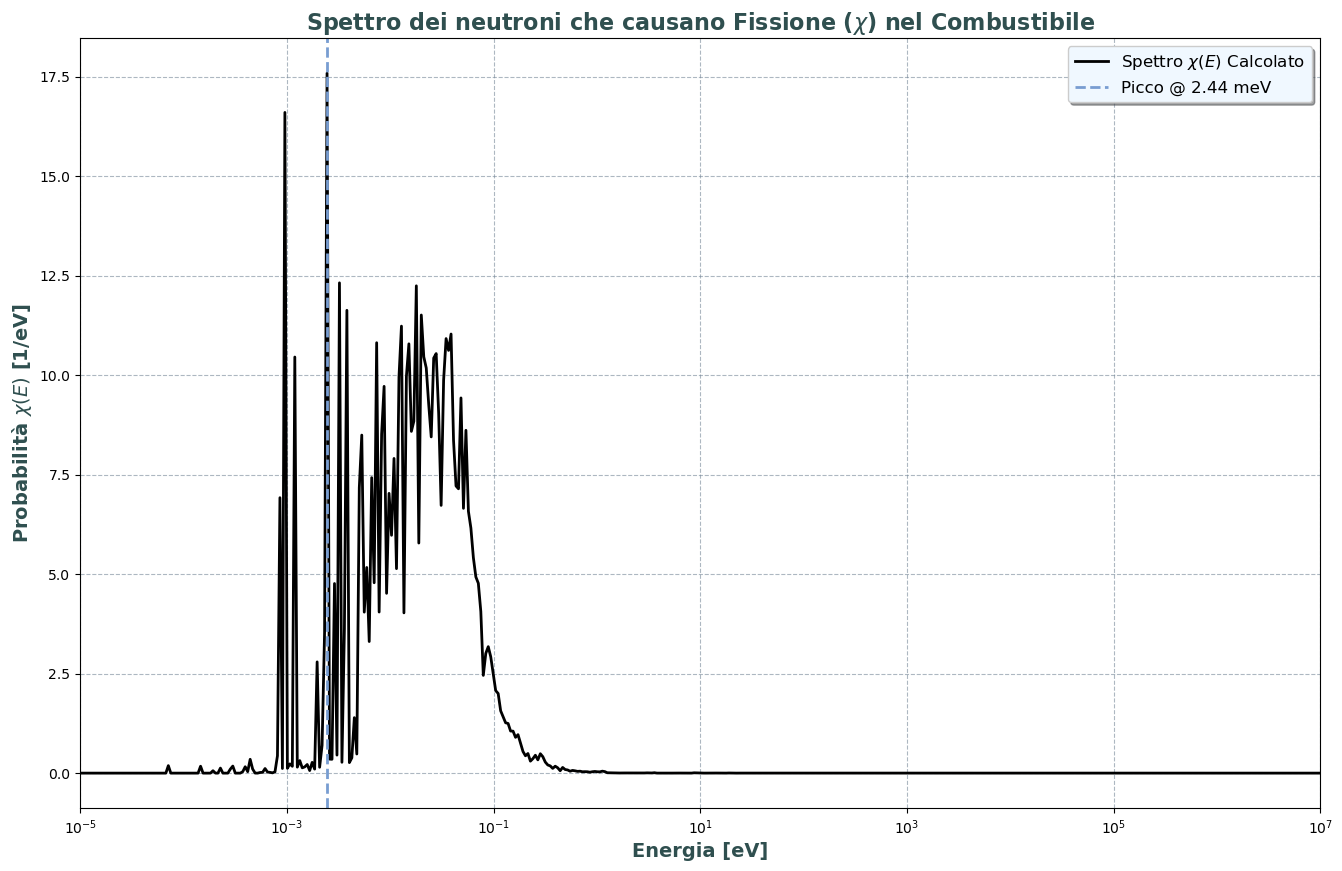

In [ ]:
tally_chi_res = sp.get_tally(name='spettro_chi')

# Estraiamo i dati grezzi (nu-fission rate per bin energetico)
# La shape sarà (Num_Energy_Bins, 1, 1) -> appiattiamo a 1D
chi_spectrum = tally_chi_res.get_values(scores=['nu-fission'], value='mean').flatten()

# --- ELABORAZIONE FISICA (Normalizzazione PDF) ---
# Per ottenere la PDF Chi(E), dobbiamo dividere per la larghezza del bin (dE)
# e normalizzare l'area totale a 1.

# 1. Recupero la griglia energetica usata nel filtro
energy_bins = np.logspace(-5, 7, 501) # Deve matchare la definizione originale
energy_mid = (energy_bins[1:] + energy_bins[:-1]) / 2 # Punti medi per il plot
dE = np.diff(energy_bins) # Larghezza dei bin

# 2. Calcolo della densità spettrale (Rate / dE)
chi_density = chi_spectrum / dE

# 3. Normalizzazione integrale (Area = 1)
# L'integrale si approssima come somma(density * dE) = somma(spectrum)
integral = np.sum(chi_spectrum)
if integral > 0:
    chi_normalized = chi_density / integral
else:
    chi_normalized = chi_density # Evita divisione per zero se vuoto

# --- PLOTTING ---
plt.figure(figsize=(16, 10))
plt.plot(energy_mid, chi_normalized, color='#000000', linewidth=2, label=r'Spettro $\chi(E)$ Calcolato')

# Formattazione
plt.title(r'Spettro dei neutroni che causano Fissione ($\chi$) nel Combustibile', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('Energia [eV]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel(r'Probabilità $\chi(E)$ [1/eV]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Scala assi
plt.xscale('log')

# Aggiungiamo una linea per evidenziare il picco
peak_energy = energy_mid[np.argmax(chi_normalized)]
plt.axvline(x=peak_energy, color='#789DD1', linestyle='--', linewidth=2, label=f'Picco @ {peak_energy*1000:.2f} meV')
plt.xlim(1e-5, 1e7)

# Legenda
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

# Griglia
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()

Visualizzazione bidimensionale della densità di fissione nel piano XY tramite mesh regolare.
Analisi spaziale del rateo di reazione normalizzato, filtrata logaritmicamente per evidenziare i gradienti tra core e zone periferiche.

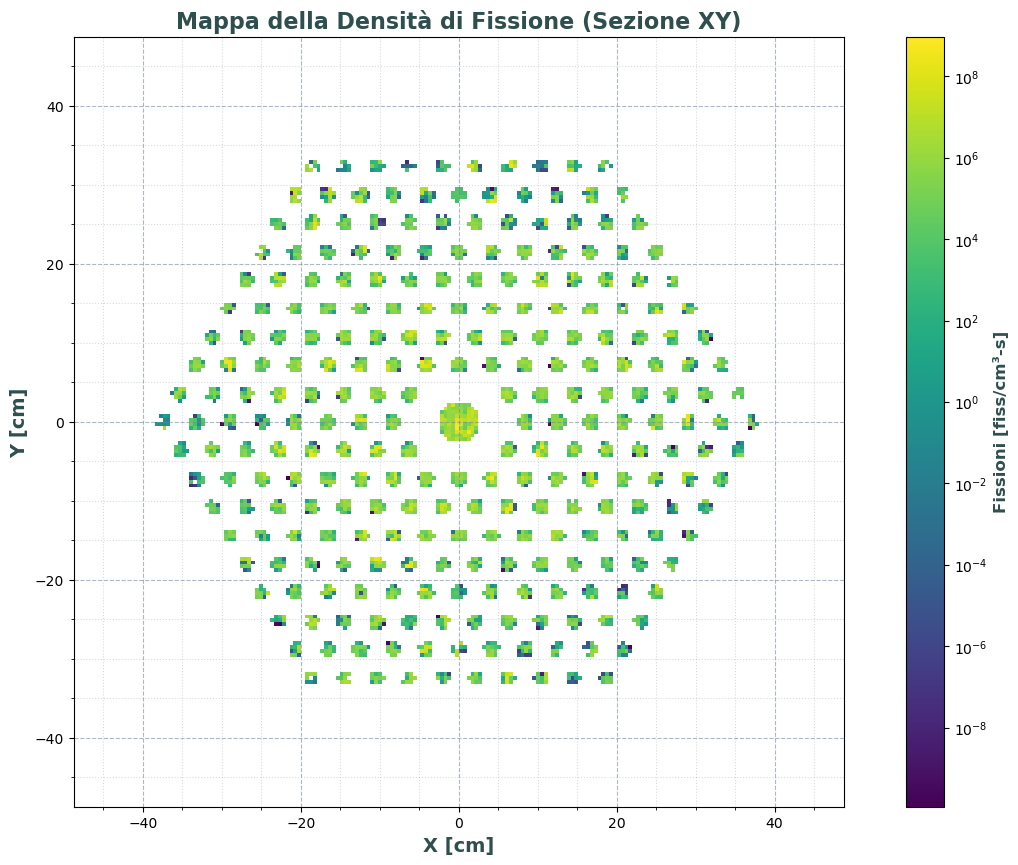

In [ ]:
tally = sp.get_tally(name='mappa_fissioni')

# Estrazione e Mascheramento
data = tally.get_values(scores=['fission'], value='mean').reshape((bin_ris,bin_ris))
data *= S

# Sostituisce i valori < 10^-20 con NaN per renderli trasparenti/non plottati
data_masked = np.where(data > 1e-10, data, np.nan)

# PLOTTING
plt.figure(figsize=(16, 10))

bound_xy = R_CORE + REF_SIDE/4 

# Setup colormap per gestire i NaN (es. bianco o grigio chiaro)
cmap = plt.cm.viridis
cmap.set_bad(color='white') 

img = plt.imshow(data_masked, extent=[-bound_xy, bound_xy, -bound_xy, bound_xy], 
                 cmap=cmap, origin='lower',
                 norm=LogNorm()) # Log scale automatica su valori validi

# Formattazione
plt.title('Mappa della Densità di Fissione (Sezione XY)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Y [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')

cbar = plt.colorbar(img)
cbar.set_label('Fissioni [fiss/cm³-s]', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia 
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()

Ricostruzione tomografica della densità di fissione sul piano longitudinale XZ.

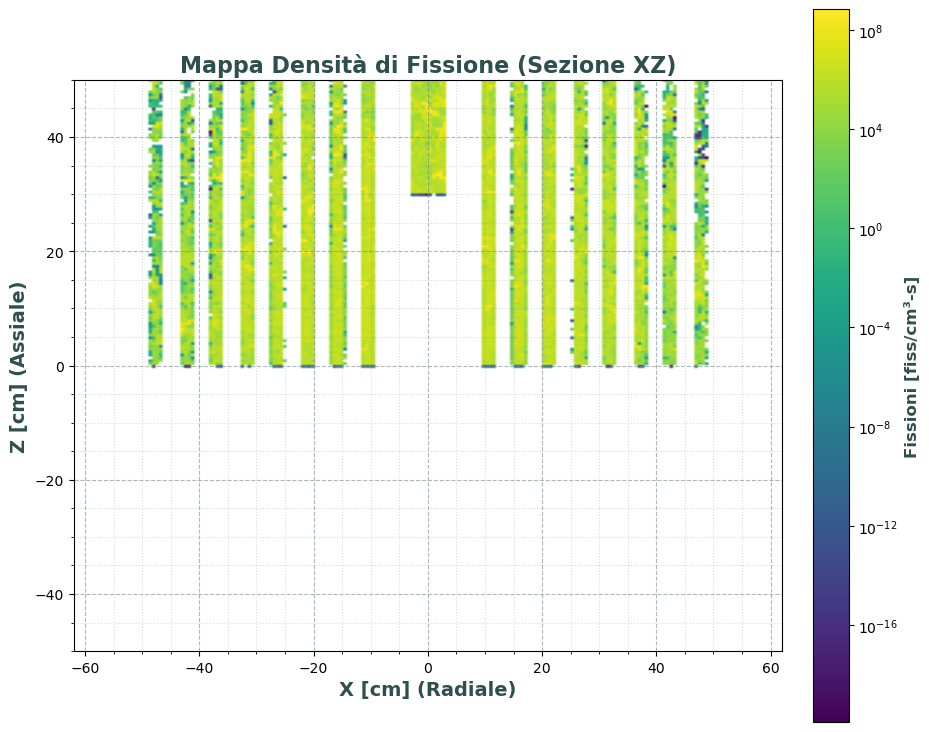

In [ ]:
# --- RECUPERO DATI XZ ---
tally_xz_res = sp.get_tally(name='mappa_fissioni_xz')

# Reshape: OpenMC ordina [x, y, z]. Con Y=1, abbiamo (X, Z).
# Per imshow vogliamo (Z, X) come righe/colonne, quindi facciamo transpose
data_xz = tally_xz_res.get_values(scores=['fission'], value='mean').reshape((bin_ris,bin_ris))
data_xz *= S

# Mascheramento (valori < 1e-20 trasparenti)
data_xz_masked = np.where(data_xz > 1e-20, data_xz, np.nan)

# --- PLOTTING ---
plt.figure(figsize=(10, 16)) # Verticale per la vista laterale

# Definiamo i bounds per l'asse Z e X
bound_x = R_CORE + REF_SIDE + 2.0
bound_z = H_CORE/2 + 5

# Colormap con gestione NaN
cmap = plt.cm.viridis
cmap.set_bad(color='white')

# Extent: [x_min, x_max, z_min, z_max]
img = plt.imshow(data_xz_masked, 
                 extent=[-bound_x, bound_x, 0, bound_z], 
                 cmap=cmap, 
                 origin='lower',
                 norm=LogNorm()) # Scala Logaritmica

# --- FORMATTAZIONE STILE UNIFICATO ---
plt.title('Mappa Densità di Fissione (Sezione XZ)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm] (Radiale)', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Z [cm] (Assiale)', fontsize=14, fontweight='bold', color='#2F4F4F')

# Colorbar
cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
cbar.set_label('Fissioni [fiss/cm³-s]', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia personalizzata
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')


plt.show()

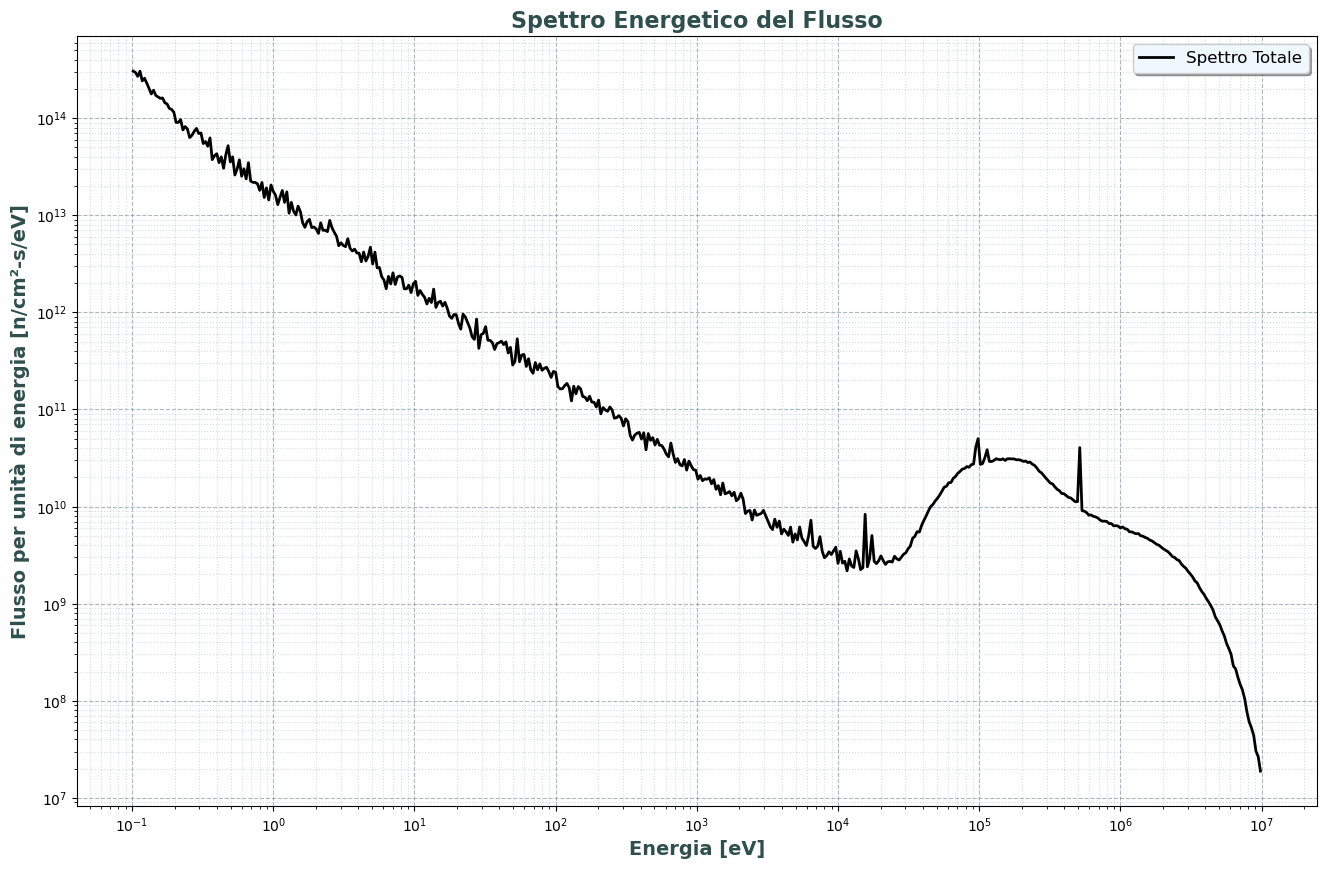

In [ ]:
# B. Spettro Energetico (Flux vs Energy)
tally_spec_res = sp.get_tally(name='spettro_energetico')
flux_spectrum = tally_spec_res.get_values(scores=['flux'], value='mean').flatten()
flux_spectrum *= S

# Gestione asse energetico (Logspace ha 501 punti -> 500 bin)
# Usiamo i punti medi dei bin per il plot
energy_bins = np.logspace(-1, 7, 501) # eV
energy_mid = (energy_bins[1:] + energy_bins[:-1]) / 2
energy_width = np.diff(energy_bins) # dE

# Calcolo Flusso per unità di letargia (o densità spettrale): Phi(E) / dE
# Questo rende l'integrale visivo corretto in scala log
flux_per_ev = flux_spectrum / energy_width

plt.figure(figsize=(16, 10))

plt.loglog(energy_mid, flux_per_ev, color='#000000', linewidth=2, label='Spettro Totale')

plt.title('Spettro Energetico del Flusso', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('Energia [eV]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Flusso per unità di energia [n/cm²-s/eV]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Legenda personalizzata
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

# Griglia
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()

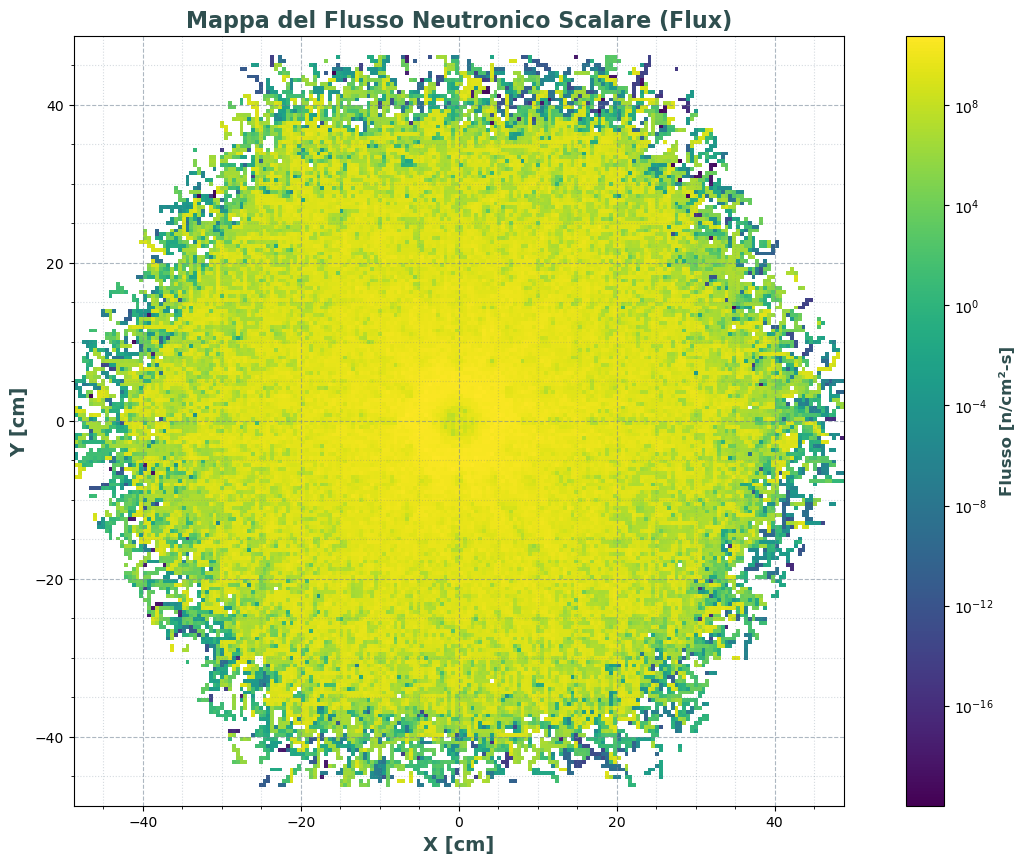

In [ ]:
# A. Mappa del Flusso (Mesh)
# Estraiamo 'flux' dalla tally mappa e rimodelliamo
tally_map_res = sp.get_tally(name='mappa_fissioni')
flux_data = tally_map_res.get_values(scores=['flux'], value='mean').reshape((bin_ris,bin_ris))
flux_data *= S  # Normalizzazione con la sorgente

# Maschera per pulire il grafico (valori spuri < 1e-20)
flux_masked = np.where(flux_data > 1e-20, flux_data, np.nan)


# --- 2. PLOTTING ---

# FIGURA 1: Mappa del Flusso Neutronico
plt.figure(figsize=(16, 10))

bound_xy = R_CORE + REF_SIDE /4 # Recupero extent dalla definizione mesh
cmap = plt.cm.viridis
cmap.set_bad(color='white')

img = plt.imshow(flux_masked, extent=[-bound_xy, bound_xy, -bound_xy, bound_xy],
                 cmap=cmap, origin='lower',
                 norm=LogNorm()) # Scala logaritmica

plt.title('Mappa del Flusso Neutronico Scalare (Flux)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Y [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Colorbar
cbar = plt.colorbar(img)
cbar.set_label('Flusso [n/cm²-s]', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()


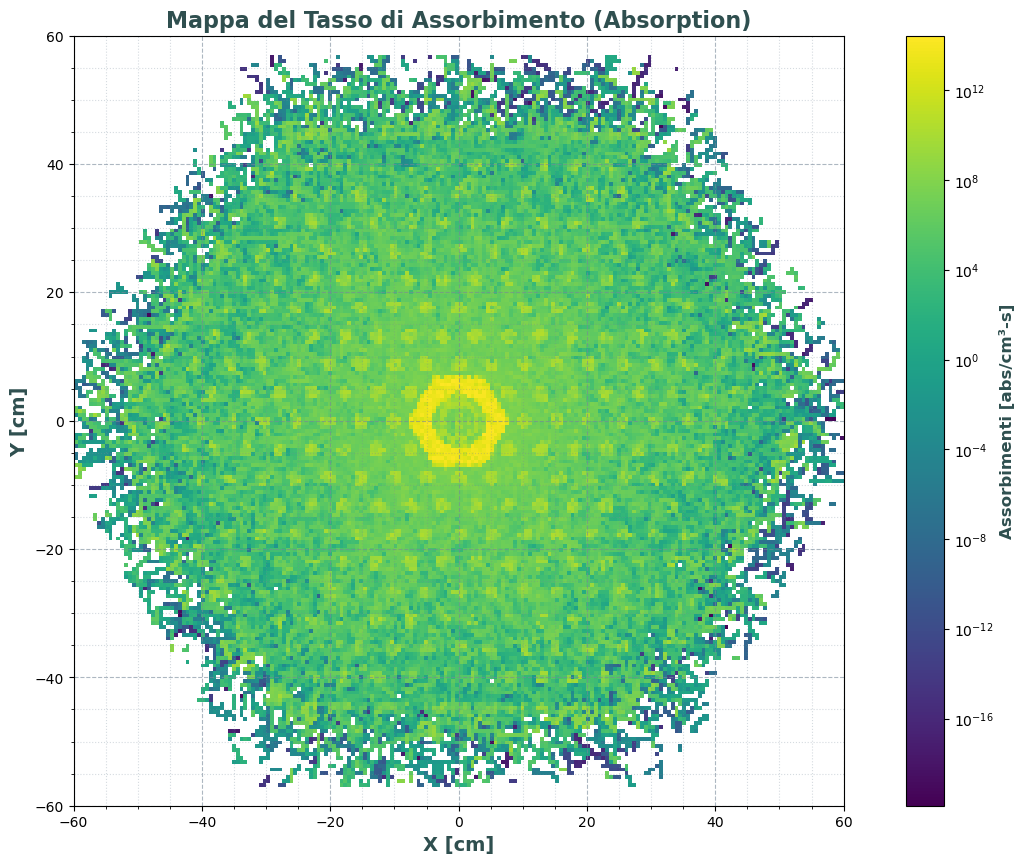

In [ ]:
# --- RECUPERO DATI ---
tally_res = sp.get_tally(name='mappa_fissioni')

# 1. Estrazione Assorbimento
abs_data = tally_res.get_values(scores=['absorption'], value='mean').reshape((bin_ris,bin_ris))
# Salviamo i dati grezzi per il calcolo del ratio, poi normalizziamo per il plot
abs_raw = abs_data.copy()
abs_data *= S

# --- MASCHERE ---
# Maschera per Assorbimento (nasconde il vuoto cosmico)
abs_masked = np.where(abs_data > 1e-20, abs_data, np.nan)


# ==========================================
# PLOT 1: TASSO DI ASSORBIMENTO (Log Scale)
# ==========================================
plt.figure(figsize=(16, 10))

bound_xy = R_CORE + REF_SIDE 
cmap = plt.cm.viridis
cmap.set_bad(color='white')

img1 = plt.imshow(abs_masked, extent=[-bound_xy, bound_xy, -bound_xy, bound_xy], 
                  cmap=cmap, origin='lower',
                  norm=LogNorm()) # Logaritmica per coprire vari ordini di grandezza

# Stile
plt.title('Mappa del Tasso di Assorbimento (Absorption)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Y [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Colorbar
cbar1 = plt.colorbar(img1)
cbar1.set_label('Assorbimenti [abs/cm³-s]', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()



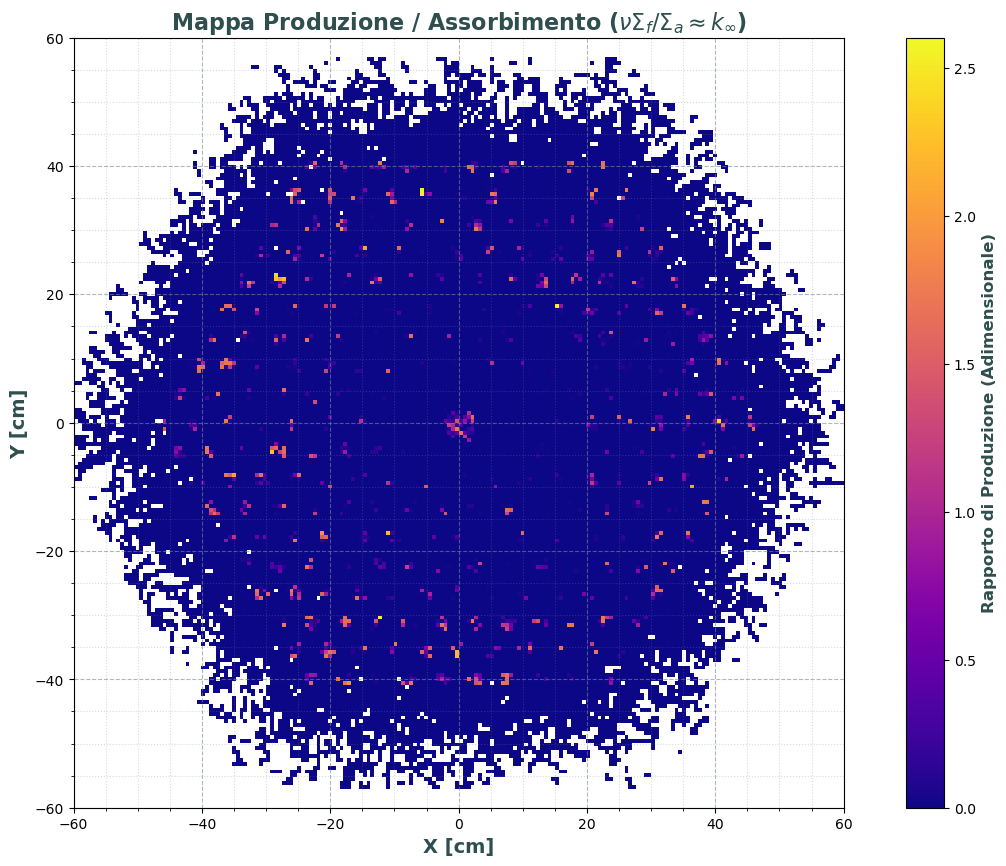

In [ ]:
# 2. Estrazione Nu-Fission (Produzione)
nu_fiss_data = tally_res.get_values(scores=['nu-fission'], value='mean').reshape((bin_ris,bin_ris))

# --- CALCOLO DEL RAPPORTO (PROXY K_INFINITO) ---
# Ratio = (Nu-Fission) / (Absorption)
# Gestiamo la divisione per zero: dove l'assorbimento è nullo o trascurabile, il ratio è 0 o NaN
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_data = np.divide(nu_fiss_data, abs_raw)
    # Pulizia: se abs è quasi 0 o il risultato è NaN/Inf, mettiamo 0
    ratio_data = np.nan_to_num(ratio_data, nan=0.0, posinf=0.0, neginf=0.0)

# Maschera per il Ratio: mostriamo solo dove c'è un assorbimento significativo
# Altrimenti il ratio nel vuoto sarebbe matematicamente instabile
ratio_masked = np.where(abs_raw > 1e-20, ratio_data, np.nan)

plt.figure(figsize=(16, 10))

# Usiamo scala lineare perché k_inf varia linearmente (es. 0 nel riflettore, >1 nel fuel)
img2 = plt.imshow(ratio_masked, extent=[-bound_xy, bound_xy, -bound_xy, bound_xy], 
                  cmap='plasma', origin='lower', # Plasma evidenzia meglio le zone "calde" (>1)
                  vmin=0, vmax=np.nanmax(ratio_masked)) 

# Stile
plt.title(r'Mappa Produzione / Assorbimento ($\nu\Sigma_f / \Sigma_a \approx k_\infty$)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Y [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Colorbar
cbar2 = plt.colorbar(img2)
cbar2.set_label('Rapporto di Produzione (Adimensionale)', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()